# Transformer decoding

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from lstnn.parcellation import Parcellation

# Parameters
cortex = 'Glasser'
cortex_res = None
scale = 1
parc = Parcellation(cortex=cortex, cortex_res=cortex_res, scale=scale)
pe_desc = "2dpe"
epoch = 4000
results = []

for target in ["motor_response", "task_condition", "visual_kmeans"]:
    df = pd.read_csv(f"../results/decoding/target-{target}_model-{pe_desc}_epoch-{epoch}.csv")
    df['target'] = target
    df['epoch'] = epoch
    results.append(df)
ann_results = pd.concat(results)

results = []
for target in ["motor_response", "task_condition", "visual_kmeans"]:
    df = pd.read_csv(f"../results/decoding/target-{target}_model-fMRI_parc-glasser_denoise-14p_stat-t.csv")
    df['target'] = target
    results.append(df)
fmri_results = pd.concat(results)

results = []
for target in ["motor_response", "task_condition", "visual_kmeans"]:
    df = pd.read_csv(f"../results/decoding/target-{target}_model-fMRI_parc-glasserNetwork_denoise-14p_stat-t.csv")
    df['target'] = target
    results.append(df)
fmri_net_results = pd.concat(results)

In [2]:
def apply_glasser_networks_to_df(df, parc, col="region"):
    network_df = pd.read_csv(parc.network_details, sep="\t")
    df["network"] = pd.NA
    # Match the network labels to roi indices
    network_labels = []
    for i, parcel in enumerate(parc.parcel_labels):
        label = network_df[network_df.GLASSERLABELNAME == parcel].NETWORK.values
        if label.size == 1:
            label = label[0]
        elif label.size == 0:
            label = 'subcortex'
        else:
            print("unknown label")
            break
        df.loc[df[col] == parcel, "network"] = label
    return df

fmri_results = apply_glasser_networks_to_df(fmri_results, parc, col="region")


## Confirm decoding the ANN looks similar to the RSA

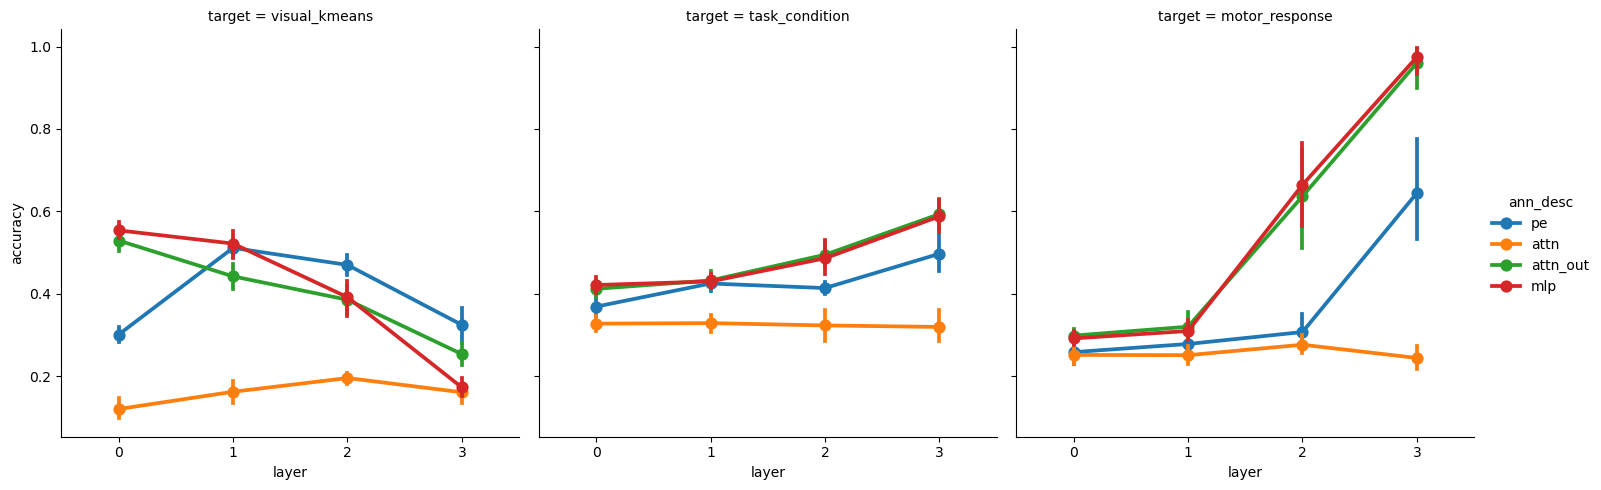

In [5]:
import seaborn as sns
x = ann_results.loc[ann_results.layer != "average"]
sns.catplot(data=x, y="accuracy", x="layer", col="target", hue="ann_desc", kind="point", col_order=["visual_kmeans", "task_condition", "motor_response"])

In [6]:
# networks_of_interest = ["Visual1", "Frontoparietal", "Somatomotor"]
# results = fmri_net_results.groupby(
#     ["network", "target"]).mean(numeric_only=True).reset_index()
# data = fmri_net_results.copy()

# for target, popmean in zip(["visual_kmeans", "task_condition", "motor_response"],
#                            [1/38, 1/3, 1/4]):

#     for network in data.network.unique():
#         a = data.loc[(data["network"] == network)
#                         & (data["target"] == target),
#                         "accuracy"]
#         res = ttest_1samp(a, popmean=popmean)
#         results.loc[(results["network"] == network)
#                     & (results["target"] == target),
#                     "t"] = res[0]
#         results.loc[(results["network"] == network)
#                     & (results["target"] == target),
#                     "p"] = np.round(res[1], 4)
        
# # for target in ["visual_kmeans", "task_condition", "motor_response"]:
# #     data = fmri_net_results.loc[(fmri_net_results.target==target)]
#     # print("FP v. V")
#     # a = grouped_data.loc[(grouped_data.network == "Frontoparietal"), "accuracy"].values
#     # b = grouped_data.loc[(grouped_data.network == "Visual1"), "accuracy"].values
#     # print(pg.ttest(a,b, paired=True))
        
# results["accuracy"] = np.round(results["accuracy"] * 100, 2)
# display(results)

In [7]:
# table with all significant results?

In [11]:
from scipy.stats import ttest_1samp
from pingouin import multicomp

data = fmri_results.loc[fmri_results["network"] != "subcortex"]
results = []
t = {}
p = {}
p_adj = {}
for target, popmean in zip(["visual_kmeans", "task_condition","motor_response"],
                            [1/38, 1/3, 1/4]):
    t = []
    p = []
    p_adj = []
    mean_decoding = []
    for region in data.region.unique():
        a = data.loc[(data["region"] == region)
                     & (data["target"] == target),
                     "accuracy"]
        res = ttest_1samp(a, popmean=popmean)
        t.append(res[0])
        p.append(res[1])
        mean_decoding.append(np.mean(a))

    # multiple comparisons within decoding target
    # (correcting across brain regions)
    res = multicomp(pvals=p, method='fdr_bh')
    print(sum(res[0]))
    p_adj = res[1]
    print(data.region.unique().tolist()[np.argmax(mean_decoding)])
    print(np.round(mean_decoding[np.argmax(mean_decoding)]*100, 2))
    print(p_adj[np.argmax(mean_decoding)].round(5))
    # organise into table
    _df = pd.DataFrame()
    _df["t"] = t
    _df["target"] = target
    _df["p"] = p
    _df["p_adj"] = p_adj
    _df["mean_decoding"] = mean_decoding
    _df["roi"] = data.region.unique().tolist()

    results.append(_df)
results = pd.concat(results)
#results = results[["target", "mean_decoding", "t", "p_adj"]]
#results.loc[results.p_adj < 0.05].to_csv("")
results.head()

97
R_V1_ROI
4.75
0.0001
360
R_8Av_ROI
58.43
0.0
41
R_3b_ROI
37.58
0.0


,t,target,p,p_adj,mean_decoding,roi
0,5.864722,visual_kmeans,7.983041e-07,0.000096,0.047454,R_V1_ROI
1,2.901276,visual_kmeans,6.080833e-03,0.029988,0.034259,R_MST_ROI
2,1.948102,visual_kmeans,5.862547e-02,0.112575,0.031944,R_V6_ROI
3,6.033124,visual_kmeans,4.658231e-07,0.000084,0.046065,R_V2_ROI
4,5.448982,visual_kmeans,3.012559e-06,0.000217,0.042361,R_V3_ROI


In [13]:
results.shape

(1080, 6)

In [20]:
n = 5

table = pd.DataFrame()

for target in ["visual_kmeans","task_condition", "motor_response"]:
    ss = results.loc[results.target == target]
    ss = ss.sort_values(by="mean_decoding", ascending=False)
    ss = ss[["target", "roi", "mean_decoding", "t", "p_adj"]]
    table = pd.concat([table, ss.head(n)])

table["mean_decoding"] = table["mean_decoding"]*100
table[["mean_decoding", "t", "p_adj"]] = table[["mean_decoding", "t", "p_adj"]].round(3)
table.to_csv("../results/decoding_summary_stats.csv", index=False)
table.head(n*3)

,target,roi,mean_decoding,t,p_adj
0,visual_kmeans,R_V1_ROI,4.745,5.865,0.000
180,visual_kmeans,L_V1_ROI,4.630,7.983,0.000
3,visual_kmeans,R_V2_ROI,4.606,6.033,0.000
183,visual_kmeans,L_V2_ROI,4.375,5.259,0.000
5,visual_kmeans,R_V4_ROI,4.352,4.565,0.002
66,task_condition,R_8Av_ROI,58.426,19.816,0.000
328,task_condition,L_PFm_ROI,58.241,22.312,0.000
148,task_condition,R_PFm_ROI,57.755,17.676,0.000
252,task_condition,L_8C_ROI,56.852,17.681,0.000
330,task_condition,L_PGs_ROI,56.667,16.154,0.000


## Plots

### Brains

In [ ]:
import nibabel as nb
import seaborn as sns
import hcp_utils as hcp
import nilearn.plotting as plotting
import matplotlib.pyplot as plt
import numpy as np


def pub_surf_plot(input_array, parcellation, save=None, size=(2.2, 2.2), thresh=None, vmin=None, vmax=None, cmap="viridis"):
    if vmax is None:
        vmax = np.nanmax(input_array)
    if vmin is None:
        vmin = np.nanmin(input_array)
    parc = np.squeeze(nb.load(parcellation).get_fdata())
    output = np.zeros((parc.shape))
    borders = np.zeros((parc.shape))
    parcels = np.unique(parc)
    parcels = np.delete(parcels, 0)  # assume 0 denotes no roi

    for i in parcels:
        index = (parc == i)
        output[index] = input_array[int(i)-1]
        borders[index] = i

    fig, axs = plt.subplot_mosaic("""
                              AB
                              CD
                              """,
                                  figsize=size, subplot_kw=dict(
                                      projection='3d'),
                                  constrained_layout=True)
    count = 0
    ax_list = ["A", "B", "C", "D"]
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            if hemi == 'left':
                surface = hcp.left_cortex_data(output)

                mesh = hcp.mesh.inflated_left
                bg_map = hcp.mesh.sulc_left

            elif hemi == 'right':
                surface = hcp.right_cortex_data(output)

                mesh = hcp.mesh.inflated_right
                bg_map = hcp.mesh.sulc_right

            if save is not None:
                plt.close("all")
                plotting.plot_surf_stat_map(mesh, surface, bg_map=bg_map, view=view, cmap=cmap, threshold=thresh,
                                            hemi=hemi, bg_on_data=True, darkness=0.75,
                                            alpha=1, vmax=vmax, vmin=vmin, colorbar=False, symmetric_cbar=False)
                plt.savefig(save+'_'+hemi+'_'+view+'.jpeg', dpi=600)
                plt.close("all")
                plotting.plot_surf_stat_map(mesh, surface, bg_map=bg_map, view=view, cmap=cmap, threshold=thresh,
                                            hemi=hemi, bg_on_data=True, darkness=0.75,
                                            alpha=1, vmax=vmax, vmin=vmin, colorbar=True, symmetric_cbar=False)
                plt.savefig(save+'_'+hemi+'_'+view+'_colorbar.jpeg', dpi=600)
                plt.close("all")

            else:

                ax = axs[ax_list[count]]

                plotting.plot_surf_stat_map(mesh, surface, bg_map=bg_map, view=view, cmap=cmap, threshold=thresh,
                                            hemi=hemi, bg_on_data=True, darkness=0.75, axes=ax,
                                            alpha=1, vmax=vmax, vmin=vmin, colorbar=False, symmetric_cbar=False)

            count = count+1

    plt.show()


def get_cropped_img(img,
                    x_start_buffer=10,
                    x_finish_buffer=10,
                    y_start_buffer=10,
                    y_finish_buffer=10,
                    ):
    # Returns a cropped input image

    # average across color information (3rd dimension)
    m_img = np.mean(img, axis=2)

    x_start = (np.where(np.argmax(m_img != np.max(img), axis=0))
               [0][0]) - x_start_buffer
    x_finish = (np.where(np.argmax(m_img != np.max(img), axis=0))
                [0][-1]) + x_finish_buffer
    y_start = np.where(np.argmax(m_img != np.max(img), axis=1))[
        0][0] - y_start_buffer
    y_finish = np.where(np.argmax(m_img != np.max(img), axis=1))[
        0][-1] + y_finish_buffer

    # Crop the input image based on determined crop heights and widths
    img_cropped = img[y_start:y_finish, x_start:x_finish, :]
    return img_cropped


In [ ]:
import cmasher as cmr

# plot the brain decoding maps
cmap = cmr.sunburst
save = False
for target, vmin, vmax in zip(["visual_kmeans", "task_condition","motor_response"],
                            [0.02, 0.3, 0.2], [0.05, 0.6, 0.4]):
    plot_data = []
    for i in parc.parcel_labels:
        data = np.mean(fmri_results.loc[(fmri_results["target"] == target)
                                        & (fmri_results["region"] == i), "accuracy"].values)
        plot_data.append(data)
    if save:
        pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/decoding-{target}", size=(2.5, 2.2), thresh=0.001, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        pub_surf_plot(np.array(plot_data), parc.file, save=None, size=(2.5, 2.2), thresh=0.001, cmap=cmap, vmin=vmin, vmax=vmax)



## Figure

In [ ]:
#4.7 inch = 1.5 panel
import matplotlib.gridspec as gridspec
#plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'
# gridspec inside gridspec
fig = plt.figure(figsize=(4.9, 4.2))

# create gridspec between brains and scatter plot
rows = gridspec.GridSpec(3, 1,
                         height_ratios=(0.25, 0.25, 0.4),
                         figure=fig, hspace=0.3, wspace=0)

# create nested gridspec for brains
bot_panel = gridspec.GridSpecFromSubplotSpec(1, 3,
                                             subplot_spec=rows[2],
                                             hspace=0, wspace=0.1)
count = 0
for target in ["visual_kmeans", "task_condition", "motor_response"]:
    brain_grid = gridspec.GridSpecFromSubplotSpec(2, 2,
                                                  subplot_spec=bot_panel[count],
                                                  hspace=-0.3, wspace=0)
    b_count = 0
    for view in ['lateral', 'medial']:
        for hemi in ['left', 'right']:

            # get image
            img = plt.imread(
                f"../figures/brain_plots/decoding-{target}_{hemi}_{view}.jpeg")
            img_cropped = get_cropped_img(img,
                                          x_start_buffer=0,
                                          x_finish_buffer=0,
                                          y_start_buffer=0,
                                          y_finish_buffer=0)

            # get ax
            ax = fig.add_subplot(brain_grid[b_count])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img_cropped, aspect='equal', rasterized=True)
            sns.despine(left=True, bottom=True, ax=ax)
            b_count = b_count+1
    count = count+1

plt.savefig("../figures/decoding.svg", dpi=1200)
plt.show()
